In [2]:
import xarray as xr
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import cmocean
import matplotlib.colors as mcolors
import matplotlib
from tqdm import tqdm
from scipy.spatial import cKDTree

In [10]:
simulations = ['ERA5', 'UBB', 'UBD', 'UBE', 'UBF']

ds_dens = {
    sim: xr.open_dataset(
        f"/project/rrg-gachon/vdemeyer/{sim}/DENSITY/density_ETCs_{sim.lower()}.nc"
    ).rename({f'density_ETCs_{sim}': 'density_ETCs'})
    for sim in simulations
}

## Counting the number of seasonal/total time steps for normalization

In [4]:
count_total = {}
count_seasonal = {}
start = f"1980-01-01 00:00:00"

for sim in simulations:
    if sim == 'ERA5':
        end = f"2023-08-31 23:00:00"
    elif sim == 'UBB':
        end = f"2023-12-31 23:00:00"
    else:
        end = f"2014-12-31 23:00:00"

    expected_time = pd.date_range(
        start=start,
        end=end,
        freq="h"
    ).to_numpy()
    
    seasons = {
        'DJF': [12, 1, 2],
        'MAM': [3, 4, 5],
        'JJA': [6, 7, 8],
        'SON': [9, 10, 11]
    }
    
    count_total[sim] = len(expected_time)
    count_seasonal[sim] = {}
    
    for season, months in seasons.items():
        season_time = [t for t in expected_time if t.astype('datetime64[M]').item().month in months]
        count_seasonal[sim][season] = len(season_time)
    
data['count_total_steps'] = count_total
data['count_seasonal_steps'] = count_seasonal

## Density over 1° gridbox

In [5]:
bin_res=1
density_1deg = {}
lat_bins_1deg = {}
lon_bins_1deg = {}

for sim in simulations:
    # extraire années
    years = df[sim]['date'].dt.year.unique()
    n_years = len(years)

    # bornes globales
    lat_bins_sim = np.arange(-90, 91, bin_res)
    lon_bins_sim = np.arange(-180, 181, bin_res)

    # histogramme des occurrences
    H, _, _ = np.histogram2d(df[sim]['lat'], df[sim]['lon'], bins=[lat_bins_sim, lon_bins_sim])

    # aire de chaque cellule (km²) sur une sphère
    R = 6371.0  # rayon Terre en km
    dlat = np.radians(bin_res)
    dlon = np.radians(bin_res)
    areas = np.zeros((len(lat_bins_sim)-1, len(lon_bins_sim)-1))
    for i in range(len(lat_bins_sim)-1):
        lat1 = np.radians(lat_bins_sim[i])
        lat2 = np.radians(lat_bins_sim[i+1])
        areas[i, :] = (R**2) * dlon * (np.sin(lat2) - np.sin(lat1))

    # densité par km² et par an
    density_sim = H / (areas * n_years)
    
    density_1deg[sim] = density_sim
    lat_bins_1deg[sim] = lat_bins_sim
    lon_bins_1deg[sim] = lon_bins_sim

## Density smoothed with gaussian weights

In [23]:
density = {}
lat2d = {}
lon2d = {}

zradius_km=100

def haversine_distance(pt, pts, R):
    dlat = pts[:,0] - pt[0]
    dlon = pts[:,1] - pt[1]
    a = np.sin(dlat/2)**2 + np.cos(pt[0])*np.cos(pts[:,0])*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

for sim in simulations:

    da = data['total_total'][sim].sel(variable='pr')

    # --- Identifier coordonnées lat/lon ---
    if 'latitude' in da.coords and 'longitude' in da.coords:
        # ERA5
        var_lat, var_lon = 'latitude', 'longitude'
        lats = da[var_lat].values
        lons = da[var_lon].values
        lon2d_sim, lat2d_sim = np.meshgrid(lons, lats)
    else:
        # Simulations régionales
        var_lat, var_lon = 'lat', 'lon'
        lat2d_sim = da[var_lat].values
        lon2d_sim = da[var_lon].values

    nlat, nlon = lat2d_sim.shape

    # --- Surface des mailles ---
    R = 6.371e6
    dlat = np.mean(np.abs(np.diff(lat2d_sim[:,0])))
    dlon = np.mean(np.abs(np.diff(lon2d_sim[0,:])))
    cell_area = (R**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(np.deg2rad(lat2d_sim))
    
    # --- Extraire points de trajectoires ---
    tab_lat, tab_lon = [], []
    for cid, group in df[sim].groupby("storm"):
        lat = group["lat"].values
        lon = group["lon"].values
        lat_interp = (lat[:-1] + lat[1:]) / 2
        lon_interp = (lon[:-1] + lon[1:]) / 2
        tab_lat.extend(np.concatenate([lat, lat_interp]))
        tab_lon.extend(np.concatenate([lon, lon_interp]))

    traj_coords = np.vstack([np.deg2rad(tab_lat), np.deg2rad(tab_lon)]).T

    # --- KDTree ---
    tree = cKDTree(traj_coords)
    radius = zradius_km * 1000.0 / R  # en radians

    # --- Boucle sur grille ---
    grid_coords = np.vstack([np.deg2rad(lat2d_sim.ravel()), np.deg2rad(lon2d_sim.ravel())]).T
    density_sim = np.zeros_like(lat2d_sim, dtype=np.float64)

    for idx, gc in enumerate(grid_coords):
        neighbors = tree.query_ball_point(gc, r=radius)
        if neighbors:
            dists = haversine_distance(gc, traj_coords[neighbors], R)
            weights = np.exp(-0.5*(dists/(zradius_km*1000.0))**2)
            density_sim.ravel()[idx] = weights.sum()
            
    density_sim = (density_sim / cell_area) * 1e6
    density_sim = density_sim / (data['count_total_steps'][sim] / (365.25*24))
    
    density[sim] = density_sim
    lat2d[sim] = lat2d_sim
    lon2d[sim] = lon2d_sim

In [25]:
import scipy.ndimage

# --- Paramètres ---
zradius_km = 100  # rayon d'influence des trajectoires
nx, ny = 200, 200 # nombre de bins dans x et y
R = 6371e3        # rayon terrestre en mètres

# Fonction pour convertir lat/lon en x/y km (projection plane locale)
def latlon_to_xy(lat, lon):
    lat0 = np.mean(lat)
    lon0 = np.mean(lon)
    x = (np.deg2rad(lon) - np.deg2rad(lon0)) * R * np.cos(np.deg2rad(lat0)) / 1000
    y = (np.deg2rad(lat) - np.deg2rad(lat0)) * R / 1000
    return x, y

# --- Dictionnaires de sortie ---
density = {}
grid_xx = {}
grid_yy = {}

# --- Définir les limites globales pour toutes les simulations ---
all_lats = np.concatenate([df[sim]["lat"].values for sim in simulations])
all_lons = np.concatenate([df[sim]["lon"].values for sim in simulations])
x_min0, y_min0 = latlon_to_xy(all_lats, all_lons)
x_min, y_min = x_min0.min(), y_min0.min()
x_max, y_max = x_min0.max(), y_min0.max()  # petit ajustement nécessaire

# --- Grille fixe ---
x_edges = np.linspace(x_min, x_max, nx+1)
y_edges = np.linspace(y_min, y_max, ny+1)
x_centers = (x_edges[:-1] + x_edges[1:])/2
y_centers = (y_edges[:-1] + y_edges[1:])/2
xx, yy = np.meshgrid(x_centers, y_centers)

# --- Boucle sur les simulations ---
for sim in simulations:
    # Extraire trajectoires
    tab_lat, tab_lon = [], []
    for cid, group in df[sim].groupby("storm"):
        lat = group["lat"].values
        lon = group["lon"].values
        lat_interp = (lat[:-1] + lat[1:]) / 2
        lon_interp = (lon[:-1] + lon[1:]) / 2
        tab_lat.extend(np.concatenate([lat, lat_interp]))
        tab_lon.extend(np.concatenate([lon, lon_interp]))
    
    tab_lat = np.array(tab_lat)
    tab_lon = np.array(tab_lon)

    # Convertir en x/y km
    x, y = latlon_to_xy(tab_lat, tab_lon)

    # Histogramme 2D brut
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])

    # Taille d'un bin en km
    bin_size_x = (x_edges[1] - x_edges[0])
    bin_size_y = (y_edges[1] - y_edges[0])
    bin_size_km = (bin_size_x + bin_size_y)/2

    # Lissage gaussien
    sigma_bins = zradius_km / bin_size_km
    density_sim = scipy.ndimage.gaussian_filter(H, sigma=sigma_bins)

    # Normalisation par le nombre d'années (si besoin)
    density_sim /= (data['count_total_steps'][sim] / (365.25*24))

    # Stockage
    density[sim] = density_sim
    grid_xx[sim] = xx
    grid_yy[sim] = yy

## Density of ETCs and EETCs over 5° gridbox

In [5]:
#Calcul de la densité sur des points de grille de 5°
lat_bins = np.arange(-90, 91, 5)
lon_bins = np.arange(-180, 181, 5)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

density_dict = {}

for sim_name, sim_df in df.items():
    hist2d, _, _ = np.histogram2d(sim_df['lat'], sim_df['lon'], bins=[lat_bins, lon_bins])
    hist2d_norm = (hist2d / data['count_total_steps'][sim_name]) * 100.
    # hist2d_smooth = gaussian_filter(hist2d_norm, sigma=0.2)
    
    density_dict[sim_name] = hist2d_norm

sim_names = list(density_dict.keys())
density_array = np.stack([density_dict[sim] for sim in sim_names], axis=0)

da_density = xr.DataArray(
    density_array,
    dims=("simulation", "lat", "lon"),
    coords={"simulation": sim_names, "lat": lat_centers, "lon": lon_centers},
    name="cyclone_density_normalized"
)

In [6]:
quantiles = [0.98, 0.99, 0.995, 0.999]

EETCs_list = {}

for sim in EETC_dict:
    EETCs_list[sim] = {
        'precip': {str(q): [] for q in quantiles},
        'wind': {str(q): [] for q in quantiles}
    }

    for storm in EETC_dict[sim]:
        for quantile in quantiles:
            q_str = str(quantile)
            storm_data = EETC_dict[sim][storm]
            
            if (
                storm_data['cum_precip'].sel(quantile=quantile).values != 0 or
                storm_data['cum_avg_precip'].sel(quantile=quantile).values != 0
            ):
                EETCs_list[sim]['precip'][q_str].append(storm)
            if (
                storm_data['cum_wind'].sel(quantile=quantile).values != 0 or
                storm_data['cum_avg_wind'].sel(quantile=quantile).values != 0
            ):
                EETCs_list[sim]['wind'][q_str].append(storm)

In [7]:
# Quantiles considérés
quantiles = [0.98, 0.99, 0.995, 0.999]

# Grilles en latitude et longitude (par exemple, 5° de bin)
lat_bins = np.arange(-90, 91, 5)
lon_bins = np.arange(-180, 181, 5)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# On initialise le dictionnaire principal pour stocker les histogrammes filtrés
density_filtered = {
    'wind': {},
    'precip': {},
    'union': {},
    'intersection': {}  # ← ajout ici
}

# Parcours des simulations
for sim_name, sim_df in df.items():
    for q in quantiles:
        q_str = str(q)
        
        # Récupération des ID de tempêtes
        wind_storms = set(EETCs_list[sim_name]['wind'][q_str])
        precip_storms = set(EETCs_list[sim_name]['precip'][q_str])
        union_storms = wind_storms.union(precip_storms)
        inter_storms = wind_storms.intersection(precip_storms)  # ← ajout ici

        # Filtrage
        filtered_dict = {
            'wind': sim_df[sim_df['storm'].isin(wind_storms)],
            'precip': sim_df[sim_df['storm'].isin(precip_storms)],
            'union': sim_df[sim_df['storm'].isin(union_storms)],
            'intersection': sim_df[sim_df['storm'].isin(inter_storms)]  # ← ajout ici
        }

        # Histogramme 2D
        for key in ['wind', 'precip', 'union', 'intersection']:  # ← modifié ici
            if sim_name not in density_filtered[key]:
                density_filtered[key][sim_name] = []
            hist2d, _, _ = np.histogram2d(
                filtered_dict[key]['lat'], filtered_dict[key]['lon'],
                bins=[lat_bins, lon_bins]
            )
            hist2d_norm = (hist2d / data['count_total_steps'][sim_name]) * 100.
            density_filtered[key][sim_name].append(hist2d_norm)

# Conversion en DataArray
density_arrays = {}

for key in ['wind', 'precip', 'union', 'intersection']:  # ← modifié ici aussi
    sim_names = list(density_filtered[key].keys())
    data_stack = []
    for sim in sim_names:
        arr = np.stack(density_filtered[key][sim], axis=0)
        data_stack.append(arr)
    final_array = np.stack(data_stack, axis=0)
    density_arrays[key] = xr.DataArray(
        final_array,
        dims=("simulation", "quantile", "lat", "lon"),
        coords={
            "simulation": sim_names,
            "quantile": quantiles,
            "lat": lat_centers,
            "lon": lon_centers
        },
        name=f"cyclone_density_{key}"
    )

In [8]:
# #Calcul de la densité (occurence) sur des points de grille de 5° en décembre
# lat_bins = np.arange(-90, 91, 5)
# lon_bins = np.arange(-180, 181, 5)
# lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
# lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# histogram_dict = {}

# for sim_name, sim_df in df.items():
#     # Filtrer pour décembre
#     sim_df_dec = sim_df[sim_df['date'].dt.month == 12].copy()

#     # Ajouter indices de bin pour lat/lon
#     sim_df_dec['lat_bin'] = np.digitize(sim_df_dec['lat'], lat_bins) - 1
#     sim_df_dec['lon_bin'] = np.digitize(sim_df_dec['lon'], lon_bins) - 1

#     # Supprimer les doublons dans un même bin pour une même tempête
#     sim_df_unique_bins = sim_df_dec.drop_duplicates(subset=['storm', 'lat_bin', 'lon_bin'])

#     # Récupérer les lat/lon correspondants aux centres des bins
#     lat_vals = lat_centers[sim_df_unique_bins['lat_bin']]
#     lon_vals = lon_centers[sim_df_unique_bins['lon_bin']]
    
#     if sim_name in ['UBD', 'UBE', 'UBF']
#         nb_dec = 36
#     elif sim_name == 'ERA5':
#         nb_dec = 44
#     elif sim_name == 'UBB':
#         nb_dec = 45
    
#     # Histogramme 2D
#     hist2d, _, _ = np.histogram2d(lat_vals, lon_vals, bins=[lat_bins, lon_bins])
    
#     histogram_dict[sim_name] = hist2d / nb_dec

# # Empilement final
# histogram_array = np.stack([histogram_dict[sim] for sim in histogram_dict.keys()], axis=0)

# da_histogram_unique = xr.DataArray(
#     histogram_array,
#     dims=("simulation", "lat", "lon"),
#     coords={"simulation": list(histogram_dict.keys()), "lat": lat_centers, "lon": lon_centers},
#     name="cyclone_unique_bin_histogram_december"
# )


# Map plots

## Function to plot the maps

In [23]:
for_pole = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/pr_ubb_199102_se.nc')
pole_lon = for_pole.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = for_pole.rotated_pole.attrs['grid_north_pole_latitude']
polecrs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)

positions = [
    [0.05, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 1
    [0.35, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 2
    [0.65, 0.48, 0.29, 0.50],  # Rangée du haut, Colonne 3
    [0.05, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 1
    [0.35, 0.18, 0.29, 0.50],  # Rangée du bas, Colonne 2
    # [0.65, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 3
]

def get_colormap(colormap_name):
    # Si l'entrée est déjà une colormap (comme cmocean.cm.curl)
    if hasattr(colormap_name, '__call__'):
        return colormap_name
    
    # Sinon, essaie de la récupérer parmi les colormaps enregistrées (matplotlib ou ajoutées comme cmocean)
    try:
        return plt.get_cmap(colormap_name)
    except ValueError:
        raise ValueError(f"Colormap '{colormap_name}' not found.")
        

def plot_map(input_dict, colormap, vmin, vmax, label, style='pcolormesh', contour_levels=None, fmt=None, cont=None, sigma=None, step=None, ting=False, cb_int=False, **kwargs):
    plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
    fig = plt.figure(figsize=(18, 16))
    axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]
        
    if vmin < 0:
        extend_opt = 'both'
    elif vmax < 100:
        extend_opt = 'max'
    else:
        extend_opt = 'neither' 
        
    if colormap == 'Spectral_r':
        spectral = matplotlib.colormaps['Spectral_r']
        colors = spectral(np.linspace(0, 1, 256))
        colors[128:145] = colors[128:145] * 0.85  # Reduce brightness at the center
        cmap = mcolors.LinearSegmentedColormap.from_list('ModifiedSpectral', colors)
    else:
        cmap = get_colormap(colormap)
        
    for i, (ax, sim) in enumerate(zip(axes, input_dict.keys())):
        if sim == 'ERA5':
            var_lat = 'latitude'
            var_lon = 'longitude'
            crs = ccrs.PlateCarree()
        else:
            var_lat = 'rlat'
            var_lon = 'rlon'
            crs = polecrs

        ax.set_extent([-130, -51, 77, 13], crs=ccrs.PlateCarree())
        borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
        states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
        lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
        lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
        img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
        ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
        ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
        ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
        ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
        ax.coastlines(resolution='10m', linewidth=0.4, color='black')
        ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
        ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())


        if style == 'pcolormesh':
            sc = ax.pcolormesh(
                input_dict[sim][var_lon], input_dict[sim][var_lat], input_dict[sim],
                transform=crs, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto'
            )
        else:
            if vmin < 0:
                absmax = max(abs(vmin), abs(vmax))
                nice_max = int(np.ceil(absmax / step)) * step  # ou /10 si tu veux plus espacé\
                vmin = -nice_max
                vmax = +nice_max
                
            if ting == True:
                levels = [0.5, 2, 5] + list(np.arange(10, vmax + step, step))
            else:
                levels = np.arange(vmin, vmax + step, step)
            
            sc = ax.contourf(
                input_dict[sim][var_lon], input_dict[sim][var_lat], input_dict[sim],
                transform=crs, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax, extend=extend_opt
            )

        if cont:
            contours = ax.contour(
                input_dict[sim][var_lat],
                input_dict[sim][var_lon],
                input_dict[sim],
                levels=contour_levels,
                colors='k',
                linewidths=2,
                alpha=0.9,
                transform=ccrs.PlateCarree(),
            )
            ax.clabel(contours, inline=True, fontsize=10, fmt=fmt)
            
        ax.text(0.98, 0.98, sim, transform=ax.transAxes, fontsize=17, fontweight='bold',
                ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # ax.contour(
        #     Mask_NNA['rlon'],
        #     Mask_NNA['rlat'],
        #     Mask_NNA,
        #     levels=[0.99],
        #     linewidths=3,
        #     colors='black',
        #     alpha=0.75,
        #     transform=polecrs,
        # )
        
    cbar_ax = fig.add_axes([0.1, 0.23, 0.8, 0.035])
    if style == 'pcolormesh':
        cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, extend=extend_opt)
    else:
        cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02)
        if cb_int:
            int_levels = [l if l == 0.5 else int(l) for l in levels]
            cbar.ax.set_xticklabels(int_levels)
        else:
            cbar.ax.set_xticklabels(levels)
    cbar.set_label(label, fontsize=18)
    cbar.ax.tick_params(labelsize=18)

## Density maps

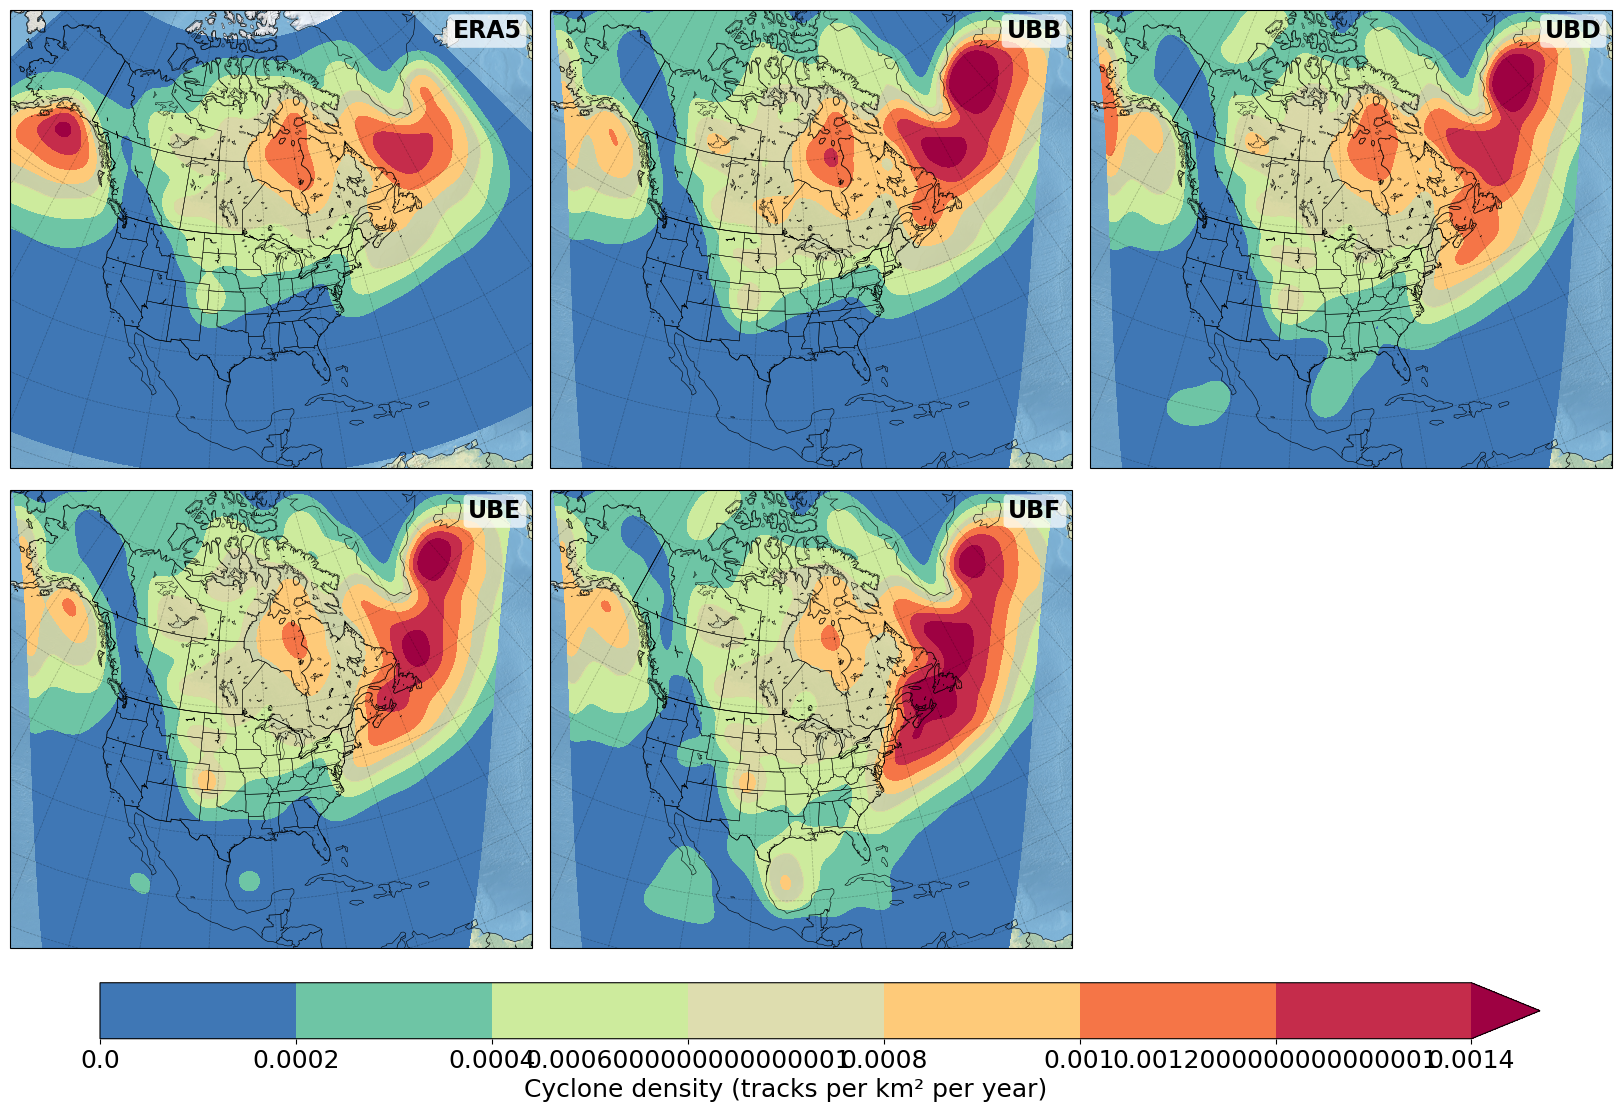

In [24]:
input_dict = {
    sim: (
        ds_dens[sim]["density_ETCs"]
    )
    for sim in ds_dens.keys()
}

    
plot_map(
    input_dict,
    colormap='Spectral_r',
    vmin=0,
    vmax=0.0014,
    step=0.0002,
    label='Cyclone density (tracks per km² per year)',
    style='contourf'
)

#plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/ETCs_density.png', dpi=120, bbox_inches='tight', transparent=True)

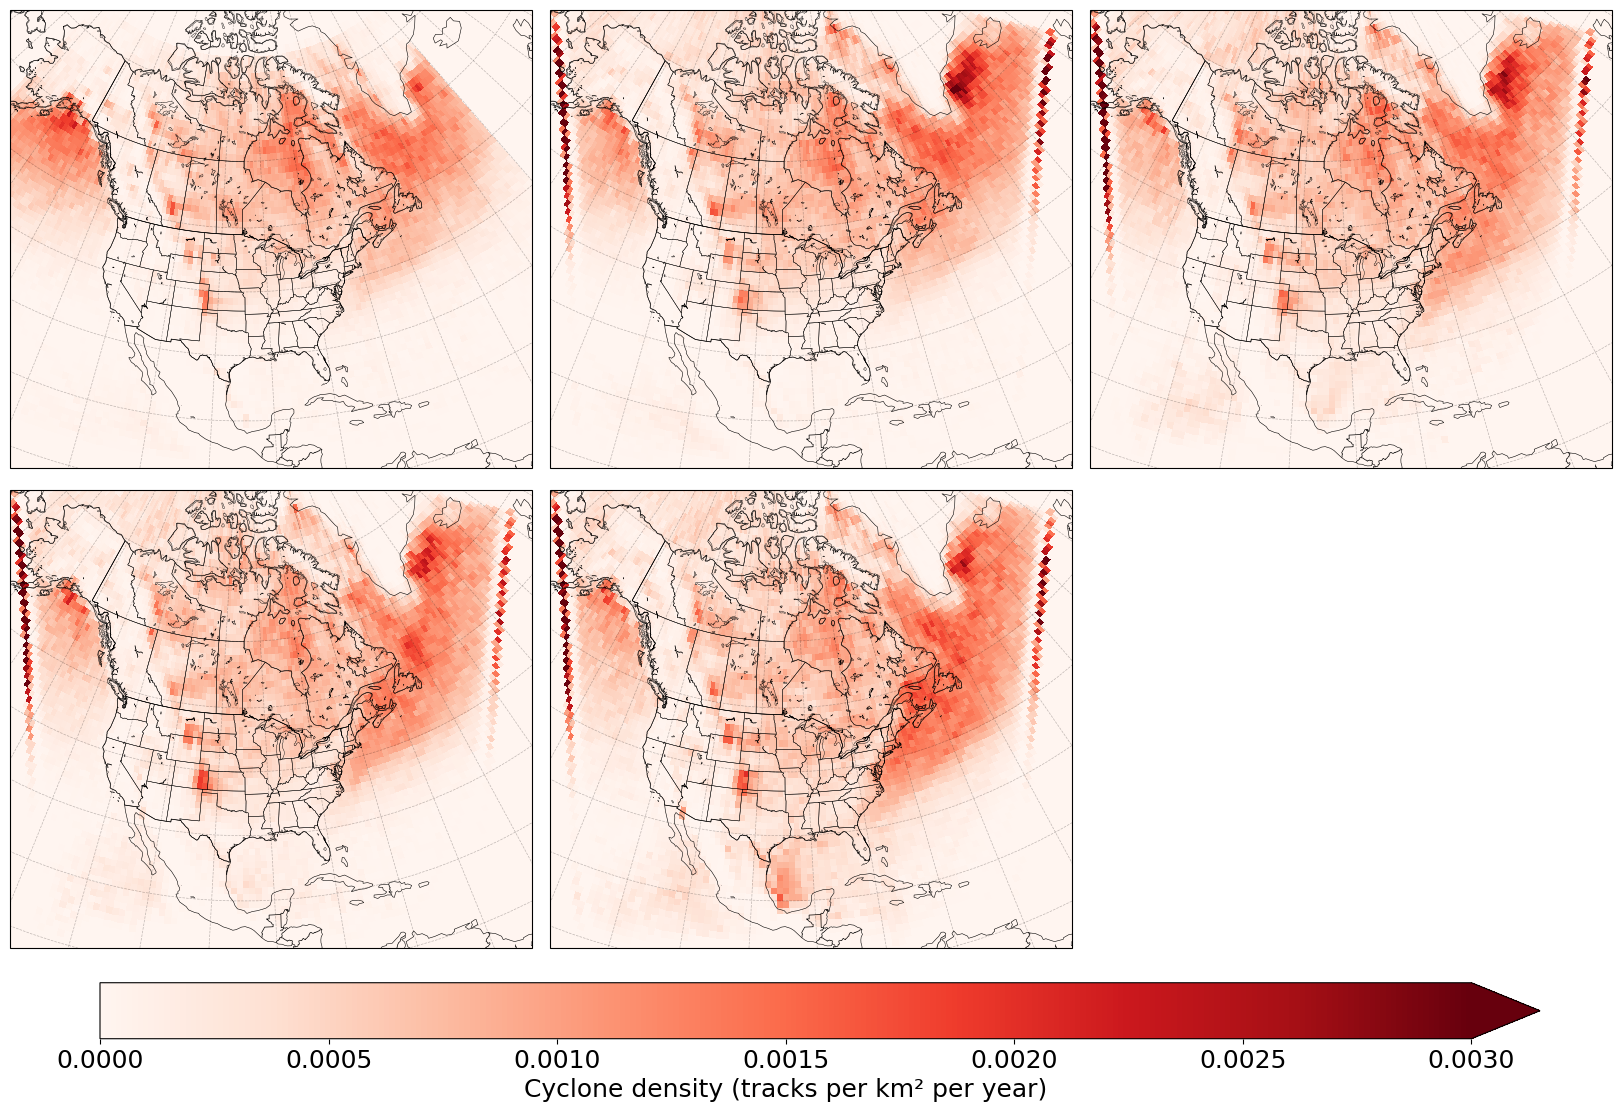

In [25]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 16))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, (ax, sim) in enumerate(zip(axes, simulations)):

    ax.set_extent([-130, -51, 77, 13], crs=ccrs.PlateCarree())
    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
    lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
    ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    mesh = ax.pcolormesh(lon_bins_1deg[sim], lat_bins_1deg[sim], density_1deg[sim], cmap='Reds', vmin=0, vmax=0.003, shading='auto', transform=ccrs.PlateCarree())

cbar_ax = fig.add_axes([0.1, 0.23, 0.8, 0.035])
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation="horizontal", pad=0.02, aspect=50, extend='max')
cbar.set_label("Cyclone density (tracks per km² per year)", fontsize=18)
cbar.ax.tick_params(labelsize=18)